<a href="https://colab.research.google.com/github/RDRamosU/cr-habilidades-demanda-tech/blob/main/notebooks/04_visualizaciones_hallazgos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto 3 — Habilidades Demandadas por Empresas Tech en Costa Rica
## Notebook 04 — Visualizaciones y hallazgos

**Autor:** Ruben Dario Ramos Ulate  
**Fecha:** Junio 2026  

---

## 1. Configuración del entorno

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'DejaVu Sans'

os.makedirs("assets/graficas", exist_ok=True)
print("Entorno configurado ✓")

Entorno configurado ✓


## 2. Reconstrucción de datasets

In [2]:
# Dataset ocupaciones
df_ocupaciones = pd.DataFrame({
    'ocupacion': [
        'Desarrollador de Software',
        'Analista de Sistemas',
        'Programador de Aplicaciones',
        'Técnico en Telecomunicaciones',
        'Operador Bilingüe Call Center'
    ],
    'nivel_ingles': ['B1-C1', 'A1', 'B1-B2', 'A1', 'B2'],
    'nivel_ingles_num': [4, 1, 3, 1, 3],
    'experiencia_min_años': [2, 2, 1, 0, 1],
    'categoria': [
        'Desarrollo', 'Análisis', 'Desarrollo',
        'Infraestructura', 'Servicios'
    ]
})

# Dataset habilidades
habilidades_data = [
    ('Desarrollador de Software', '.NET', 'Framework', 'Avanzado'),
    ('Desarrollador de Software', 'Angular', 'Framework', 'Avanzado'),
    ('Desarrollador de Software', 'SQL', 'Base de datos', 'Avanzado'),
    ('Desarrollador de Software', 'Oracle', 'Base de datos', 'Avanzado'),
    ('Desarrollador de Software', 'Java', 'Lenguaje', 'Intermedio'),
    ('Desarrollador de Software', 'JavaScript', 'Lenguaje', 'Intermedio'),
    ('Desarrollador de Software', 'HTML5', 'Frontend', 'Avanzado'),
    ('Desarrollador de Software', 'CSS3', 'Frontend', 'Básico'),
    ('Desarrollador de Software', 'CCNA', 'Certificación', 'Avanzado'),
    ('Desarrollador de Software', 'Apache/PHP/MySQL', 'Backend', 'Intermedio'),
    ('Analista de Sistemas', 'SQL', 'Base de datos', 'Avanzado'),
    ('Analista de Sistemas', 'Excel avanzado', 'Herramienta', 'Avanzado'),
    ('Analista de Sistemas', 'UML', 'Metodología', 'Intermedio'),
    ('Analista de Sistemas', 'ITIL', 'Certificación', 'Básico'),
    ('Analista de Sistemas', 'Python', 'Lenguaje', 'Básico'),
    ('Programador de Aplicaciones', 'Java', 'Lenguaje', 'Avanzado'),
    ('Programador de Aplicaciones', 'JavaScript', 'Lenguaje', 'Avanzado'),
    ('Programador de Aplicaciones', 'Python', 'Lenguaje', 'Intermedio'),
    ('Programador de Aplicaciones', 'SQL', 'Base de datos', 'Intermedio'),
    ('Programador de Aplicaciones', 'Git', 'Herramienta', 'Intermedio'),
    ('Técnico en Telecomunicaciones', 'CCNA', 'Certificación', 'Avanzado'),
    ('Técnico en Telecomunicaciones', 'TCP/IP', 'Protocolo', 'Avanzado'),
    ('Técnico en Telecomunicaciones', 'Redes LAN/WAN', 'Infraestructura', 'Intermedio'),
    ('Operador Bilingüe Call Center', 'CRM', 'Herramienta', 'Básico'),
    ('Operador Bilingüe Call Center', 'Office 365', 'Herramienta', 'Básico'),
]
df_habilidades = pd.DataFrame(habilidades_data,
    columns=['ocupacion', 'habilidad',
             'categoria_habilidad', 'nivel_requerido'])

# Dataset competencias
df_competencias = pd.DataFrame({
    'competencia': [
        'Compromiso ético y honestidad',
        'Compromiso con la calidad',
        'Trabajo en equipo interdisciplinario',
        'Capacidad para aprender y actualizarse',
        'Identificar y resolver problemas',
        'Comunicación oral y escrita',
        'Uso de tecnologías de información',
        'Pensamiento crítico y analítico',
        'Gestión del tiempo y prioridades',
        'Adaptabilidad al cambio'
    ],
    'puntuacion': [4.93, 4.87, 4.81, 4.80, 4.79,
                   4.75, 4.72, 4.70, 4.65, 4.60],
    'tipo': [
        'Blanda', 'Blanda', 'Blanda', 'Técnica-adaptativa',
        'Técnica-analítica', 'Blanda', 'Técnica',
        'Técnica-analítica', 'Blanda', 'Blanda'
    ]
})

# Dataset brechas
df_brechas = pd.DataFrame({
    'brecha': [
        'Inglés B1-C1',
        'Frameworks modernos (Angular, React)',
        'Cloud computing (AWS, Azure)',
        'Certificaciones (CCNA, ITIL, Scrum)',
        'Habilidades blandas',
        'Bases de datos avanzadas',
        'DevOps y CI/CD',
        'Ciberseguridad'
    ],
    'impacto': [
        'Crítico', 'Alto', 'Alto', 'Alto',
        'Medio', 'Medio', 'Medio', 'Medio'
    ],
    'impacto_num': [4, 3, 3, 3, 2, 2, 2, 2],
    'cubre_sistema_universitario': [
        'Parcialmente', 'No', 'No', 'No',
        'Parcialmente', 'Sí', 'No', 'Parcialmente'
    ],
    'score_prioridad': [8, 9, 9, 9, 4, 2, 6, 4]
})

print("Todos los datasets reconstruidos ✓")

Todos los datasets reconstruidos ✓


## 3. Visualización 1 — Nivel de inglés requerido por ocupación tech

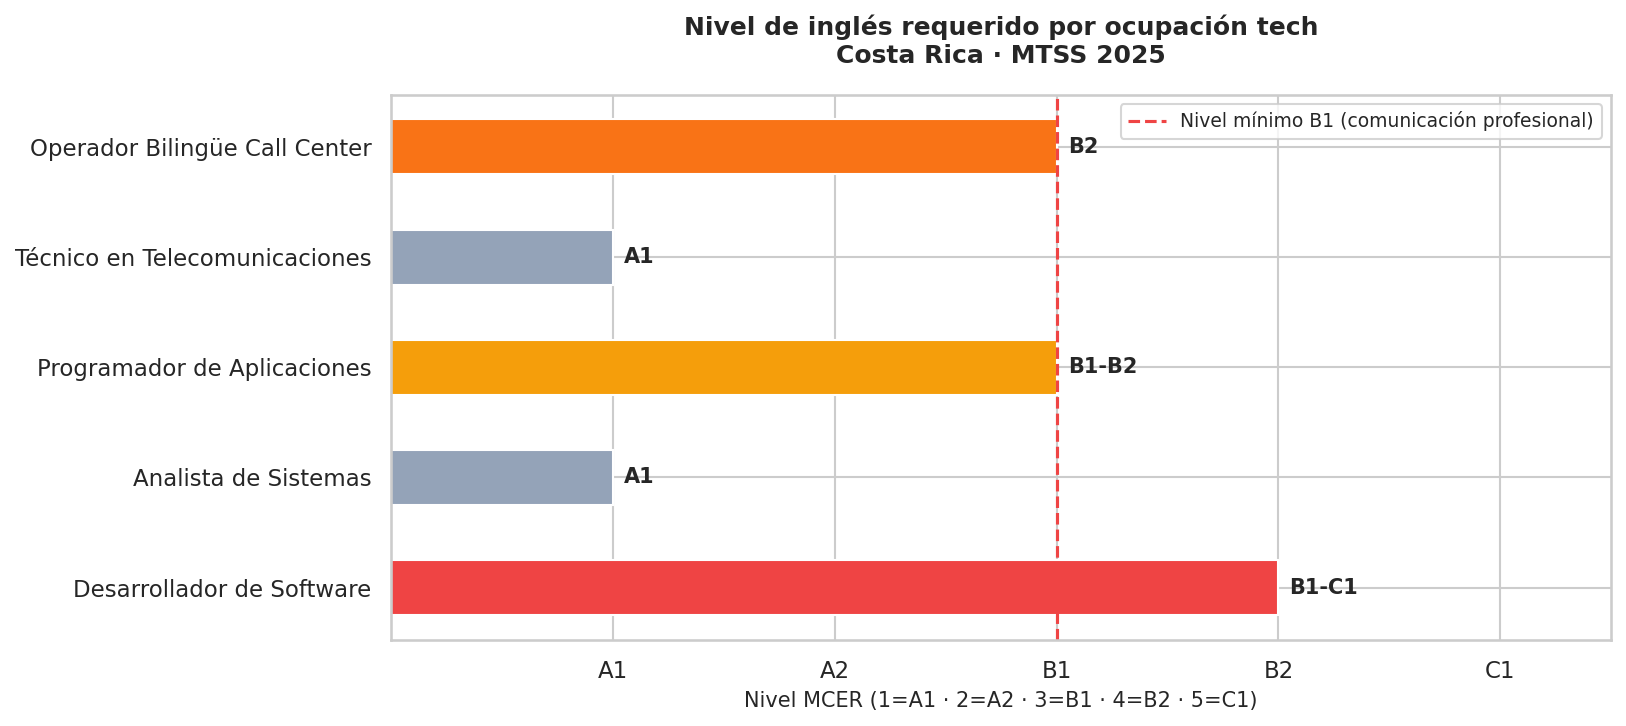

Gráfica 1 exportada ✓


In [3]:
fig, ax = plt.subplots(figsize=(11, 5))

colores_ingles = {
    'A1': '#94A3B8', 'A2': '#64748B',
    'B1-B2': '#F59E0B', 'B1-C1': '#EF4444', 'B2': '#F97316'
}
colores = [colores_ingles.get(n, '#2563EB')
           for n in df_ocupaciones['nivel_ingles']]

bars = ax.barh(df_ocupaciones['ocupacion'],
               df_ocupaciones['nivel_ingles_num'],
               color=colores, edgecolor='white', height=0.5)

for bar, nivel in zip(bars, df_ocupaciones['nivel_ingles']):
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height()/2,
            nivel, va='center', fontsize=10, fontweight='bold')

ax.axvline(x=3, color='#EF4444', linestyle='--',
           linewidth=1.5, label='Nivel mínimo B1 (comunicación profesional)')

ax.set_title('Nivel de inglés requerido por ocupación tech\n'
             'Costa Rica · MTSS 2025',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Nivel MCER (1=A1 · 2=A2 · 3=B1 · 4=B2 · 5=C1)',
              fontsize=10)
ax.set_xlim(0, 5.5)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("assets/graficas/01_ingles_por_ocupacion.png",
            bbox_inches='tight')
plt.show()
print("Gráfica 1 exportada ✓")

## 4. Visualización 2 — Habilidades técnicas más demandadas

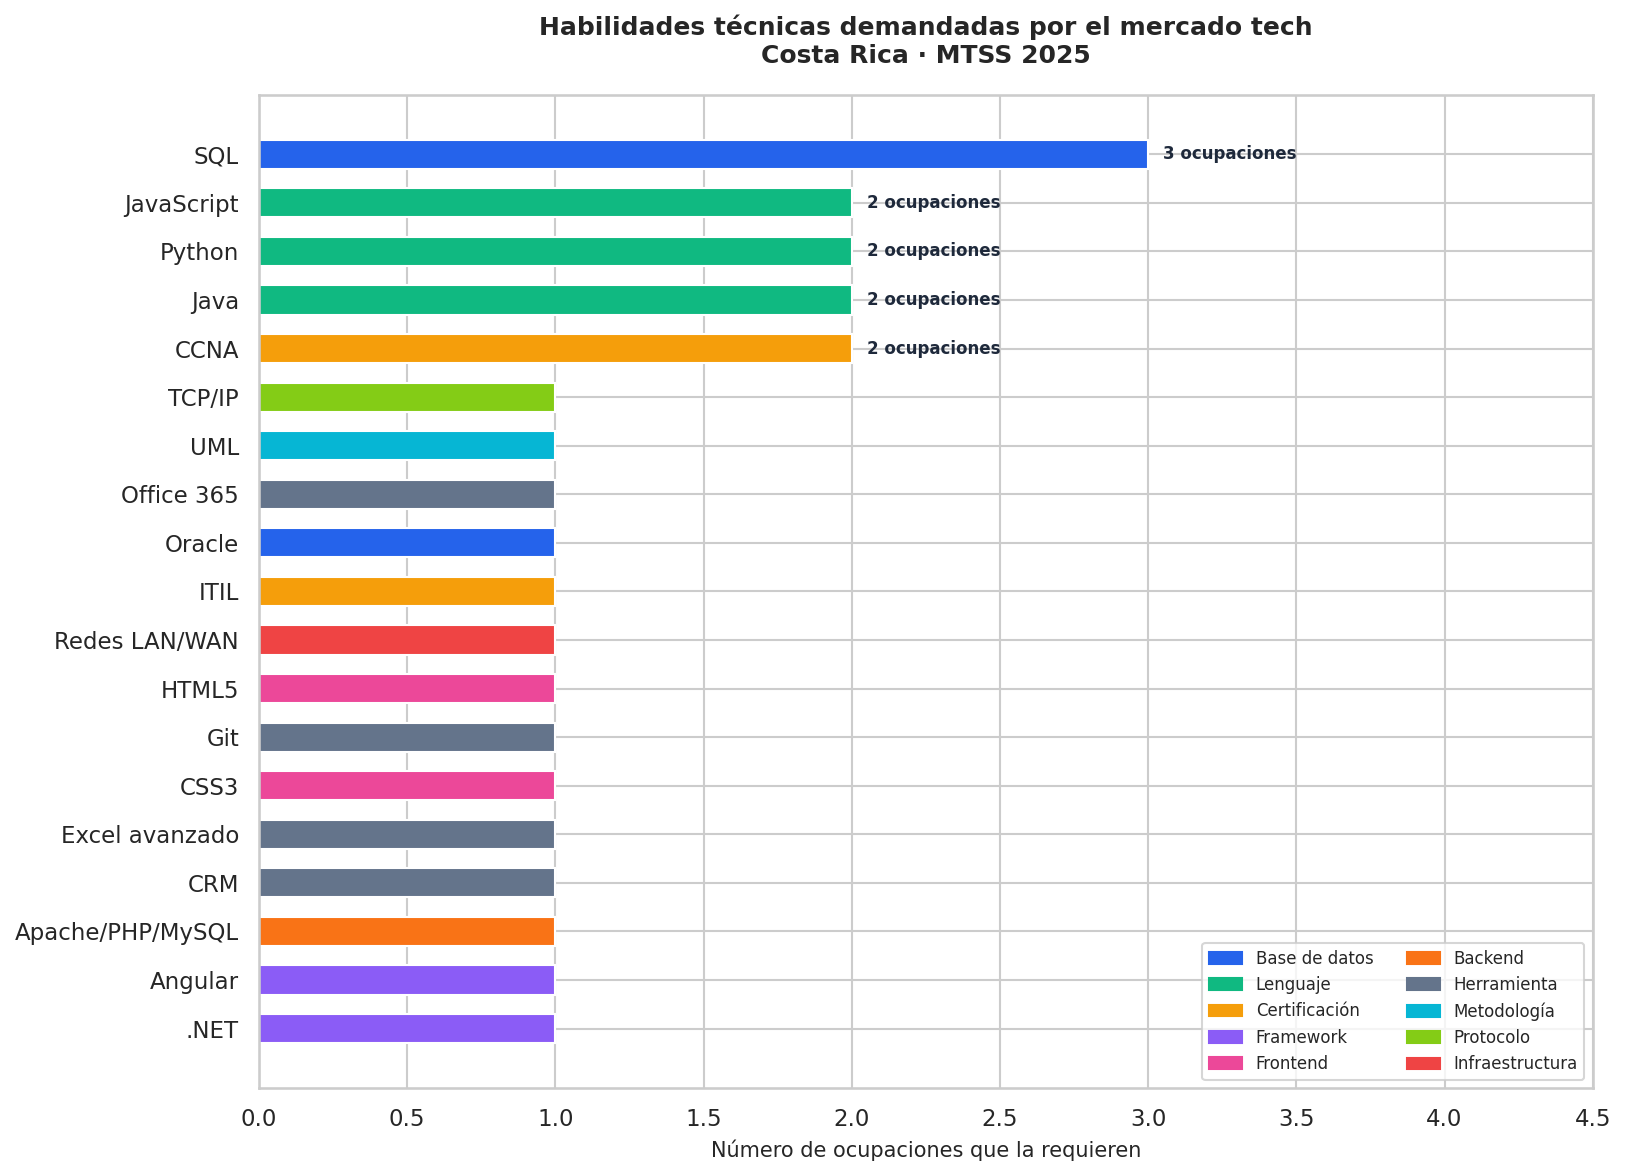

Gráfica 2 exportada ✓


In [4]:
# Frecuencia de habilidades por categoría
habilidades_count = (df_habilidades
    .groupby(['habilidad', 'categoria_habilidad'])
    .size()
    .reset_index(name='n_ocupaciones')
    .sort_values('n_ocupaciones', ascending=True)
)

colores_cat = {
    'Base de datos': '#2563EB',
    'Lenguaje': '#10B981',
    'Certificación': '#F59E0B',
    'Framework': '#8B5CF6',
    'Frontend': '#EC4899',
    'Backend': '#F97316',
    'Herramienta': '#64748B',
    'Metodología': '#06B6D4',
    'Protocolo': '#84CC16',
    'Infraestructura': '#EF4444'
}

fig, ax = plt.subplots(figsize=(11, 8))

colores = [colores_cat.get(c, '#94A3B8')
           for c in habilidades_count['categoria_habilidad']]

bars = ax.barh(habilidades_count['habilidad'],
               habilidades_count['n_ocupaciones'],
               color=colores, edgecolor='white', height=0.6)

for bar, val in zip(bars, habilidades_count['n_ocupaciones']):
    if val > 1:
        ax.text(val + 0.05,
                bar.get_y() + bar.get_height()/2,
                f'{int(val)} ocupaciones',
                va='center', fontsize=8,
                fontweight='bold', color='#1E293B')

# Leyenda de categorías
patches = [mpatches.Patch(color=v, label=k)
           for k, v in colores_cat.items()
           if k in habilidades_count['categoria_habilidad'].values]
ax.legend(handles=patches, fontsize=8,
          loc='lower right', ncol=2)

ax.set_title('Habilidades técnicas demandadas por el mercado tech\n'
             'Costa Rica · MTSS 2025',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Número de ocupaciones que la requieren', fontsize=10)
ax.set_xlim(0, 4.5)

plt.tight_layout()
plt.savefig("assets/graficas/02_habilidades_demandadas.png",
            bbox_inches='tight')
plt.show()
print("Gráfica 2 exportada ✓")

## 5. Visualización 3 — Competencias valoradas por empleadores STEM

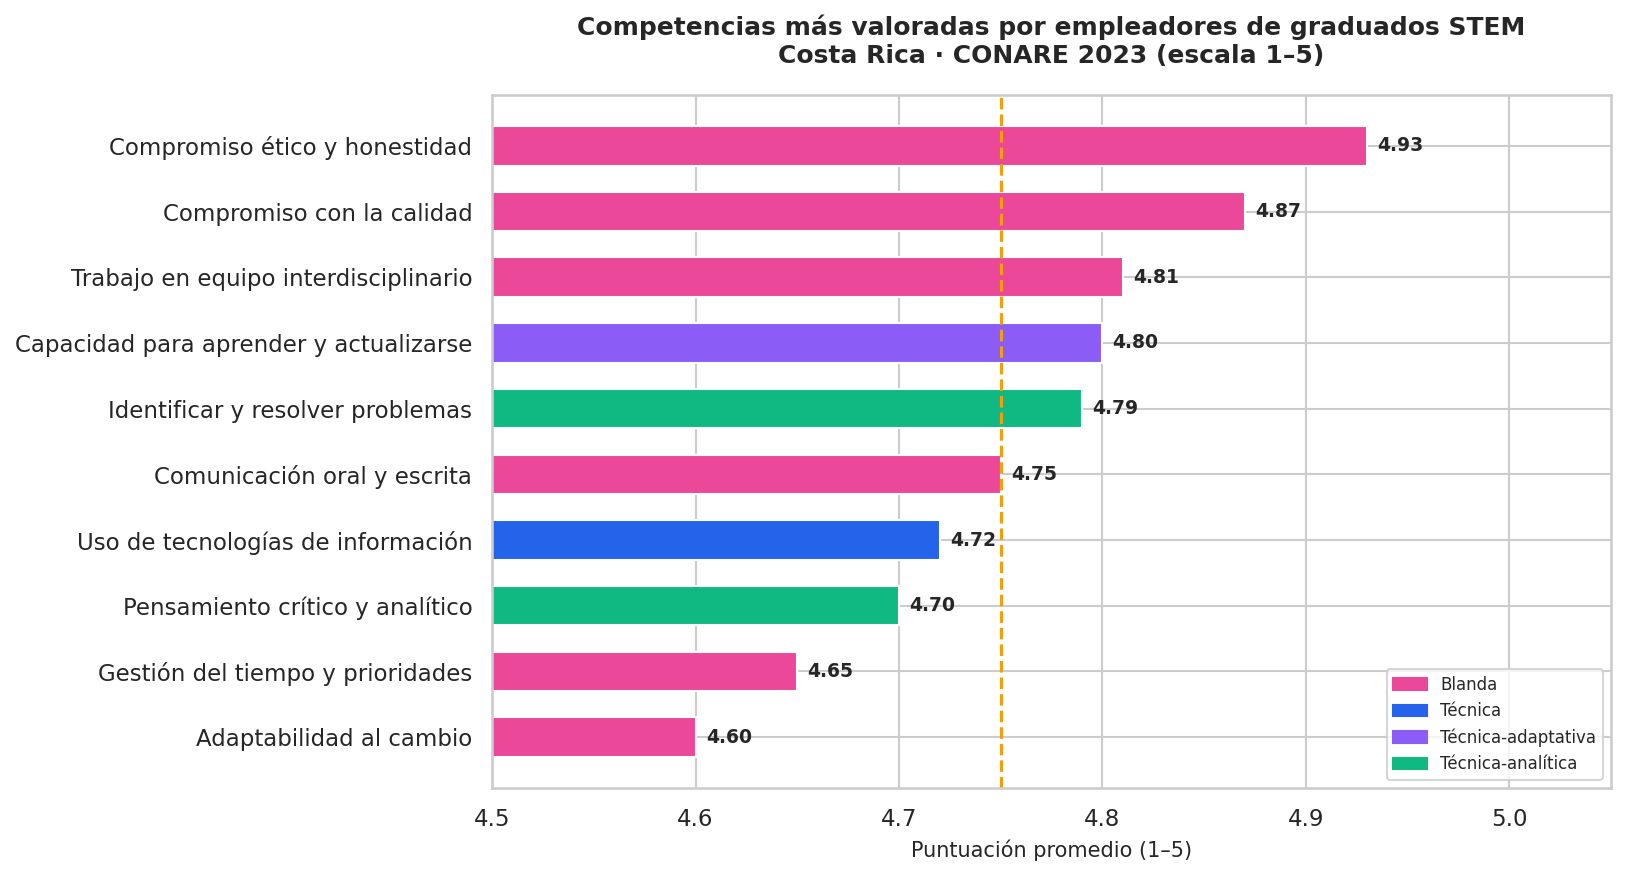

Gráfica 3 exportada ✓


In [5]:
fig, ax = plt.subplots(figsize=(11, 6))

df_comp_sorted = df_competencias.sort_values(
    'puntuacion', ascending=True)

colores_tipo = {
    'Blanda': '#EC4899',
    'Técnica': '#2563EB',
    'Técnica-adaptativa': '#8B5CF6',
    'Técnica-analítica': '#10B981'
}
colores = [colores_tipo.get(t, '#94A3B8')
           for t in df_comp_sorted['tipo']]

bars = ax.barh(df_comp_sorted['competencia'],
               df_comp_sorted['puntuacion'],
               color=colores, edgecolor='white', height=0.6)

for bar, val in zip(bars, df_comp_sorted['puntuacion']):
    ax.text(val + 0.005,
            bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center',
            fontsize=9, fontweight='bold')

ax.axvline(x=4.75, color='#F59E0B', linestyle='--',
           linewidth=1.5, label='Promedio: 4.76')
ax.set_xlim(4.5, 5.05)

patches = [mpatches.Patch(color=v, label=k)
           for k, v in colores_tipo.items()]
ax.legend(handles=patches, fontsize=8)

ax.set_title('Competencias más valoradas por empleadores de graduados STEM\n'
             'Costa Rica · CONARE 2023 (escala 1–5)',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Puntuación promedio (1–5)', fontsize=10)

plt.tight_layout()
plt.savefig("assets/graficas/03_competencias_empleadores.png",
            bbox_inches='tight')
plt.show()
print("Gráfica 3 exportada ✓")

## 6. Visualización 4 — Mapa de brechas por prioridad

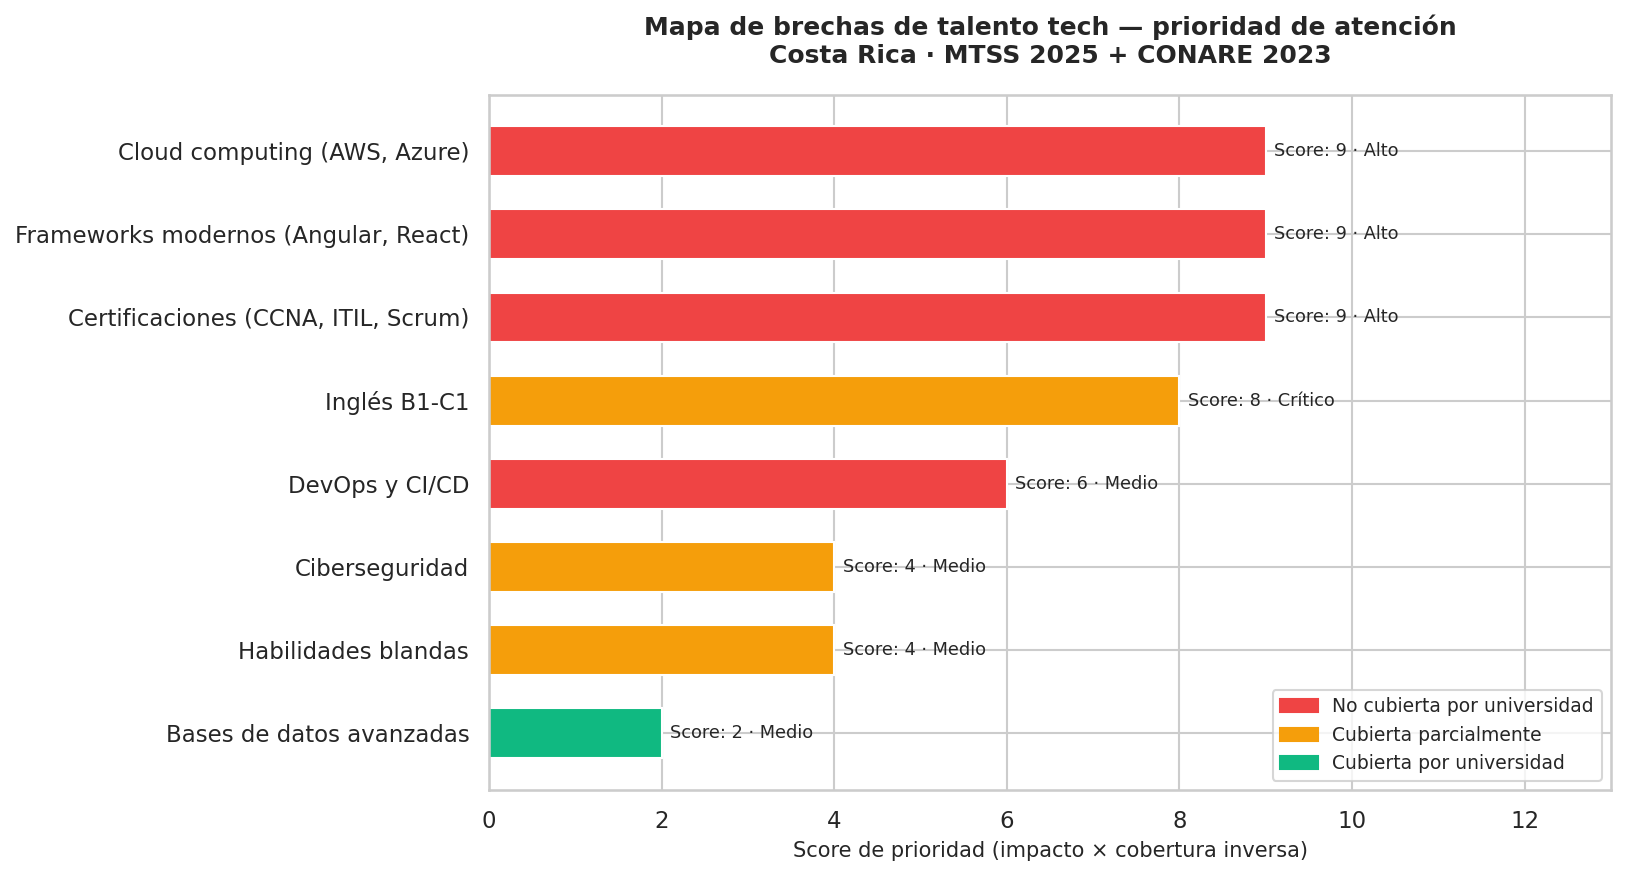

Gráfica 4 exportada ✓


In [6]:
fig, ax = plt.subplots(figsize=(11, 6))

colores_cobertura = {
    'No': '#EF4444',
    'Parcialmente': '#F59E0B',
    'Sí': '#10B981'
}
colores = [colores_cobertura[c]
           for c in df_brechas['cubre_sistema_universitario']]

df_brechas_sorted = df_brechas.sort_values(
    'score_prioridad', ascending=True)

colores_sorted = [colores_cobertura[c]
                  for c in df_brechas_sorted['cubre_sistema_universitario']]

bars = ax.barh(df_brechas_sorted['brecha'],
               df_brechas_sorted['score_prioridad'],
               color=colores_sorted, edgecolor='white', height=0.6)

for bar, row in zip(bars, df_brechas_sorted.itertuples()):
    ax.text(bar.get_width() + 0.1,
            bar.get_y() + bar.get_height()/2,
            f'Score: {row.score_prioridad} · {row.impacto}',
            va='center', fontsize=8.5)

patches = [
    mpatches.Patch(color='#EF4444', label='No cubierta por universidad'),
    mpatches.Patch(color='#F59E0B', label='Cubierta parcialmente'),
    mpatches.Patch(color='#10B981', label='Cubierta por universidad'),
]
ax.legend(handles=patches, fontsize=9)

ax.set_title('Mapa de brechas de talento tech — prioridad de atención\n'
             'Costa Rica · MTSS 2025 + CONARE 2023',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Score de prioridad (impacto × cobertura inversa)',
              fontsize=10)
ax.set_xlim(0, 13)

plt.tight_layout()
plt.savefig("assets/graficas/04_mapa_brechas_prioridad.png",
            bbox_inches='tight')
plt.show()
print("Gráfica 4 exportada ✓")

## 7. Hallazgos principales

In [7]:
print("=" * 58)
print("HALLAZGOS — HABILIDADES DEMANDADAS TECH CR 2025")
print("=" * 58)

print("\n1. HABILIDADES TRANSVERSALES MÁS DEMANDADAS")
transversales = (df_habilidades
    .groupby('habilidad')
    .size()
    .reset_index(name='n')
    .query('n > 1')
    .sort_values('n', ascending=False))
for _, row in transversales.iterrows():
    print(f"   {row['habilidad']}: {row['n']} ocupaciones")

print("\n2. INGLÉS — REQUISITO CRÍTICO")
promedio_ingles = df_ocupaciones['nivel_ingles_num'].mean()
print(f"   Nivel promedio requerido: {promedio_ingles:.1f}/5.0")
print(f"   3 de 5 ocupaciones exigen B1 o superior")
print(f"   Desarrollador de Software: hasta C1")

print("\n3. BRECHAS CON MAYOR URGENCIA (score ≥ 9)")
criticas = df_brechas[df_brechas['score_prioridad'] >= 9]
for _, row in criticas.iterrows():
    print(f"   {row['brecha']} — {row['impacto']} · "
          f"NO cubierta por universidad")

print("\n4. COMPETENCIAS BLANDAS VS TÉCNICAS")
blandas_prom = df_competencias[
    df_competencias['tipo'] == 'Blanda']['puntuacion'].mean()
tecnicas_prom = df_competencias[
    df_competencias['tipo'].str.contains('Técnica')]['puntuacion'].mean()
print(f"   Blandas promedio:  {blandas_prom:.2f}/5.00")
print(f"   Técnicas promedio: {tecnicas_prom:.2f}/5.00")
print(f"   Las blandas superan levemente a las técnicas")

print("\n5. COBERTURA DEL SISTEMA UNIVERSITARIO")
no_cubre = df_brechas[
    df_brechas['cubre_sistema_universitario'] == 'No']
print(f"   4 de 8 brechas NO son cubiertas: "
      f"{', '.join(no_cubre['brecha'].tolist())}")

print("\n" + "=" * 58)

HALLAZGOS — HABILIDADES DEMANDADAS TECH CR 2025

1. HABILIDADES TRANSVERSALES MÁS DEMANDADAS
   SQL: 3 ocupaciones
   CCNA: 2 ocupaciones
   Java: 2 ocupaciones
   JavaScript: 2 ocupaciones
   Python: 2 ocupaciones

2. INGLÉS — REQUISITO CRÍTICO
   Nivel promedio requerido: 2.4/5.0
   3 de 5 ocupaciones exigen B1 o superior
   Desarrollador de Software: hasta C1

3. BRECHAS CON MAYOR URGENCIA (score ≥ 9)
   Frameworks modernos (Angular, React) — Alto · NO cubierta por universidad
   Cloud computing (AWS, Azure) — Alto · NO cubierta por universidad
   Certificaciones (CCNA, ITIL, Scrum) — Alto · NO cubierta por universidad

4. COMPETENCIAS BLANDAS VS TÉCNICAS
   Blandas promedio:  4.77/5.00
   Técnicas promedio: 4.75/5.00
   Las blandas superan levemente a las técnicas

5. COBERTURA DEL SISTEMA UNIVERSITARIO
   4 de 8 brechas NO son cubiertas: Frameworks modernos (Angular, React), Cloud computing (AWS, Azure), Certificaciones (CCNA, ITIL, Scrum), DevOps y CI/CD



## 8. Conclusiones

1. **SQL, Java y JavaScript son la base:** aparecen en múltiples
   ocupaciones y con nivel intermedio a avanzado. Son las habilidades
   mínimas para entrar al mercado tech costarricense.

2. **El inglés es la barrera de entrada más crítica:** requerido en
   todos los perfiles tech, con nivel B1-C1 para posiciones de
   desarrollo. El sistema universitario no garantiza este nivel.

3. **Cuatro brechas estructurales sin cobertura universitaria:**
   frameworks modernos, cloud computing, certificaciones y DevOps.
   Estas se cubren principalmente mediante formación autodidacta,
   bootcamps o capacitación empresarial.

4. **Los empleadores valoran más las competencias blandas** que las
   técnicas, con compromiso ético y trabajo en equipo al tope.
   Esto complementa perfectamente las habilidades técnicas.

5. **El mercado tech CR demanda un perfil híbrido:** sólido en
   fundamentos técnicos (SQL, Java, JavaScript), competente en inglés
   B1+, y con habilidades blandas bien desarrolladas.

---
*Fuentes: MTSS OML 2025 · CONARE-OPES 2023*  
*Análisis: Ruben Dario Ramos Ulate · rubendario.dev*